In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

In [47]:
df = pd.read_csv('fordgobike-tripdataFor201902.csv')
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [48]:
df[['user_type', 'member_gender', 'member_birth_year']].isnull().sum()

user_type               0
member_gender        8265
member_birth_year    8265
dtype: int64

In [49]:
df['member_gender'] = df['member_gender'].fillna('Other')
df['member_birth_year'] = df['member_birth_year'].fillna(df['member_birth_year'].median())

df[['user_type', 'member_gender', 'member_birth_year']].isnull().sum()

user_type            0
member_gender        0
member_birth_year    0
dtype: int64

In [50]:
print('Duplicates before:', df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('Duplicates after:', df.duplicated().sum())

Duplicates before: 4
Duplicates after: 0


In [51]:
df['user_type'] = df['user_type'].astype('category')
df['member_gender'] = df['member_gender'].astype('category')
df.dtypes[['user_type', 'member_gender', 'member_birth_year']]

user_type            category
member_gender        category
member_birth_year     float64
dtype: object

In [52]:
df['Age'] = (2019 - df['member_birth_year']).astype('int64')
df[['member_birth_year', 'Age']].head()

,member_birth_year,Age
0,1984.0,35
1,1987.0,32
2,1972.0,47
3,1989.0,30
4,1974.0,45


### 1) Distribution of `user_type`

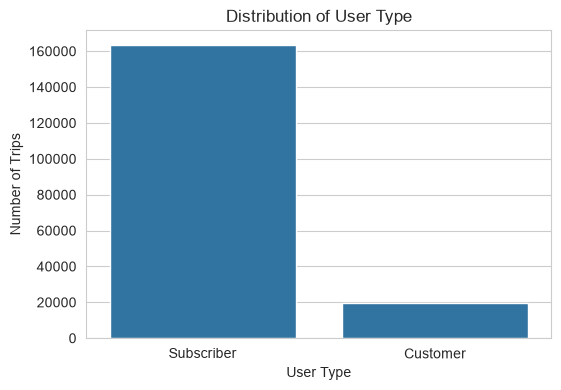

user_type
Subscriber    89.167557
Customer      10.832443
Name: proportion, dtype: float64

In [53]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='user_type', order=df['user_type'].value_counts().index)
plt.title('Distribution of User Type')
plt.xlabel('User Type')
plt.ylabel('Number of Trips')
plt.show()

df['user_type'].value_counts(normalize=True) * 100

**Insight:** "89% Subscribers vs  11% Customers" the large majority of trips are made by **Subscribers**, while **Customers** (casual/one-time riders) make up a much smaller share. This suggests the service's core user base is regular commuters rather than tourists or occasional users.

### 2) Distribution of `member_gender`

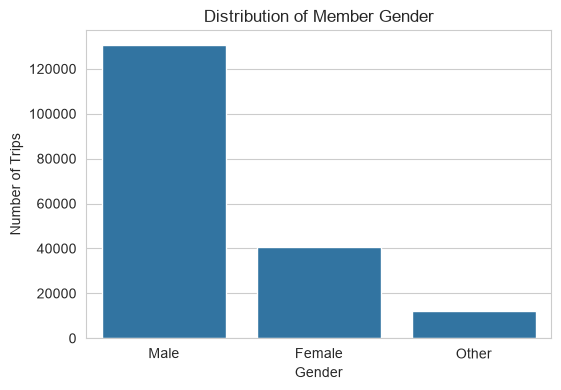

member_gender
Male      71.233616
Female    22.268990
Other      6.497394
Name: proportion, dtype: float64

In [54]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='member_gender', order=df['member_gender'].value_counts().index)
plt.title('Distribution of Member Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Trips')
plt.show()

df['member_gender'].value_counts(normalize=True) * 100

**Insight:** Males make up the majority of riders, followed by Females, with a small 'Other' category (riders who didn't disclose a Male/Female gender or had missing data filled as 'Other').

### 3) Distribution of `Age`

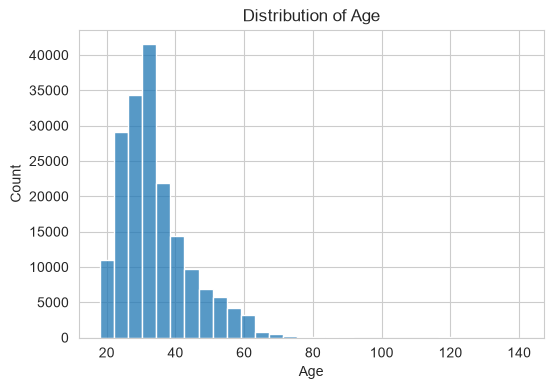

count    183412.000000
mean         34.094716
std           9.896585
min          18.000000
25%          27.000000
50%          32.000000
75%          38.000000
max         141.000000
Name: Age, dtype: float64

In [55]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='Age', bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

df['Age'].describe()

In [56]:
mean_age = df['Age'].mean()
median_age = df['Age'].median()
print('Mean:', mean_age, '| Median:', median_age, '| Skew:', df['Age'].skew())

Mean: 34.09471572198111 | Median: 32.0 | Skew: 1.3986898772007232


**Insight:** Since `mean > median` and `skew() > 0`, the Age distribution is **Right-skewed**. 50% of riders are between 27 and 38 years old (IQR) shown above, with a long tail of older ages pulling the mean upward.

### 4) Age outliers

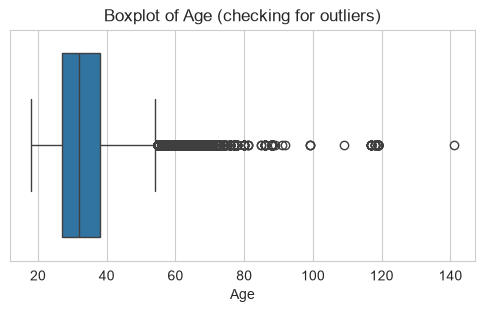

Riders older than 80: 192
Max age: 141


In [57]:
plt.figure(figsize=(6,3))
sns.boxplot(x=df['Age'])
plt.title('Boxplot of Age (checking for outliers)')
plt.xlabel('Age')
plt.show()

print('Riders older than 80:', (df['Age'] > 80).sum())
print('Max age:', df['Age'].max())

**Insight:** There are clear outliers — a small number of riders show implausibly high ages (well above 80, up to the max shown), most likely due to incorrect/very old birth years entered in the source data.

## relationships between the variables

### 1) `user_type` vs `member_gender`

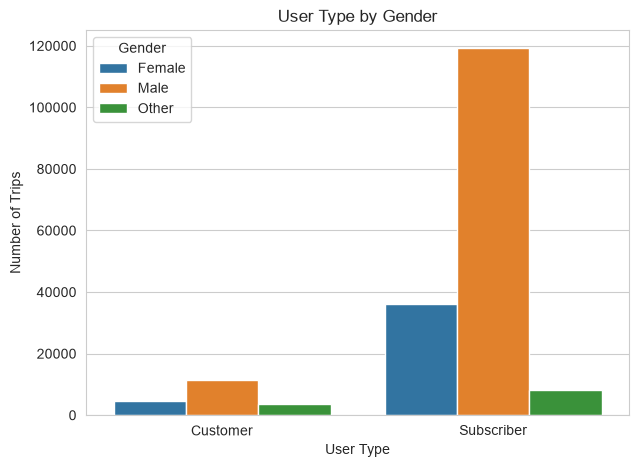

member_gender,Female,Male,Other
user_type,,,
Customer,23.389370,58.027985,18.582645
Subscriber,22.132882,72.837891,5.029228


In [58]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='user_type', hue='member_gender')
plt.title('User Type by Gender')
plt.xlabel('User Type')
plt.ylabel('Number of Trips')
plt.legend(title='Gender')
plt.show()

pd.crosstab(df['user_type'], df['member_gender'], normalize='index') * 100

**Insight:** Males are the majority in both groups, but higher among Subscribers (72.8%) than Customers (58%). The clearest gap is in 'Other': 18.6% for Customers vs. only 5% for Subscribers 

### 2) `user_type` vs `Age`

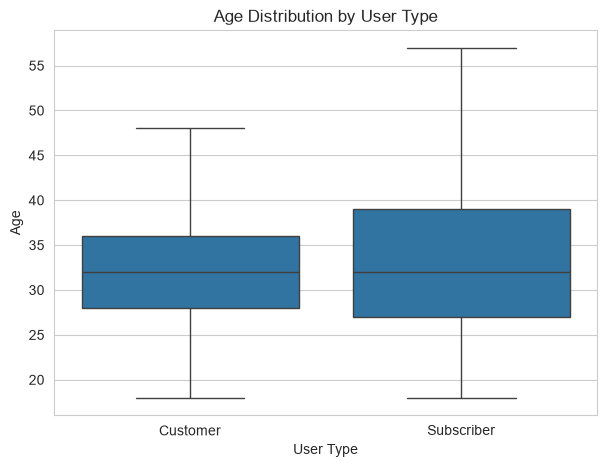

,count,mean,std,min,25%,50%,75%,max
user_type,,,,,,,,
Customer,19868.0,33.371905,8.693430,18.0,28.0,32.0,36.0,141.0
Subscriber,163544.0,34.182526,10.029401,18.0,27.0,32.0,39.0,119.0


In [59]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='user_type', y='Age', showfliers=False)
plt.title('Age Distribution by User Type')
plt.xlabel('User Type')
plt.ylabel('Age')
plt.show()

df.groupby('user_type', observed=True)['Age'].describe()

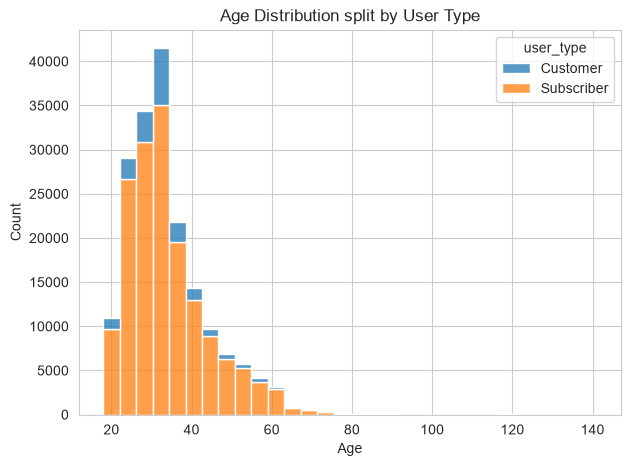

In [60]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='Age', hue='user_type', bins=30, multiple='stack')
plt.title('Age Distribution split by User Type')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

**Insight:** Median age is the same for both types (32 years), but Subscribers show a wider age spread (IQR 27–39 vs. 28–36 for Customers). The one extreme outlier (age 141) belongs to a Customer, not a Subscriber.

---
## Summary of  Insights

- **User type:** Subscribers dominate the platform, indicating a commuter-driven user base.
- **Gender:** Male riders are the majority across the dataset and across both user types.
- **Age:** The typical rider is a young/middle-aged adult; the distribution is right-skewed with some unrealistic outliers (very old ages) that should be flagged as data quality issues, not a real trend.
- **User type × Gender:** Gender split is similar between the two types, except 'Other' is much more common among Customers (18.6% vs 5%).
- **User type × Age:** Median age is identical (32) for both types; Subscribers just have a wider age range.